In [1]:
import os
import pandas as pd

# Paths to the train and test directories
train_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/train'
test_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/test'

# Class labels corresponding to folder names
labels_dict = {
    'F': 'Atrial Fibrillation',
    'M': 'Murmur',
    'N': 'Normal',
    'Q': 'Premature Ventricular Contraction',
    'S': 'Supraventricular Tachycardia',
    'V': 'Ventricular Tachycardia'
}

# Function to extract paths and labels
def get_paths_and_labels(directory):
    paths = []
    labels = []
    for folder in os.listdir(directory):
        folder_path = os.path.join(directory, folder)
        if os.path.isdir(folder_path):  # Check if it's a directory
            label = labels_dict.get(folder, 'Unknown')  # Get label based on folder name
            for filename in os.listdir(folder_path):
                file_path = os.path.join(folder_path, filename)
                paths.append(file_path)
                labels.append(label)
    return paths, labels

# Get train paths and labels
train_paths, train_labels = get_paths_and_labels(train_dir)

# Get test paths and labels
test_paths, test_labels = get_paths_and_labels(test_dir)

# Combine train and test data
all_paths = train_paths + test_paths
all_labels = train_labels + test_labels

# Create a DataFrame
df = pd.DataFrame({
    'path': all_paths,
    'label': all_labels
})




In [2]:
df

,path,label
0,/kaggle/input/ecg-image-data/ECG_Image_data/tr...,Normal
1,/kaggle/input/ecg-image-data/ECG_Image_data/tr...,Normal
2,/kaggle/input/ecg-image-data/ECG_Image_data/tr...,Normal
3,/kaggle/input/ecg-image-data/ECG_Image_data/tr...,Normal
4,/kaggle/input/ecg-image-data/ECG_Image_data/tr...,Normal
...,...,...
123993,/kaggle/input/ecg-image-data/ECG_Image_data/te...,Ventricular Tachycardia
123994,/kaggle/input/ecg-image-data/ECG_Image_data/te...,Ventricular Tachycardia
123995,/kaggle/input/ecg-image-data/ECG_Image_data/te...,Ventricular Tachycardia
123996,/kaggle/input/ecg-image-data/ECG_Image_data/te...,Ventricular Tachycardia


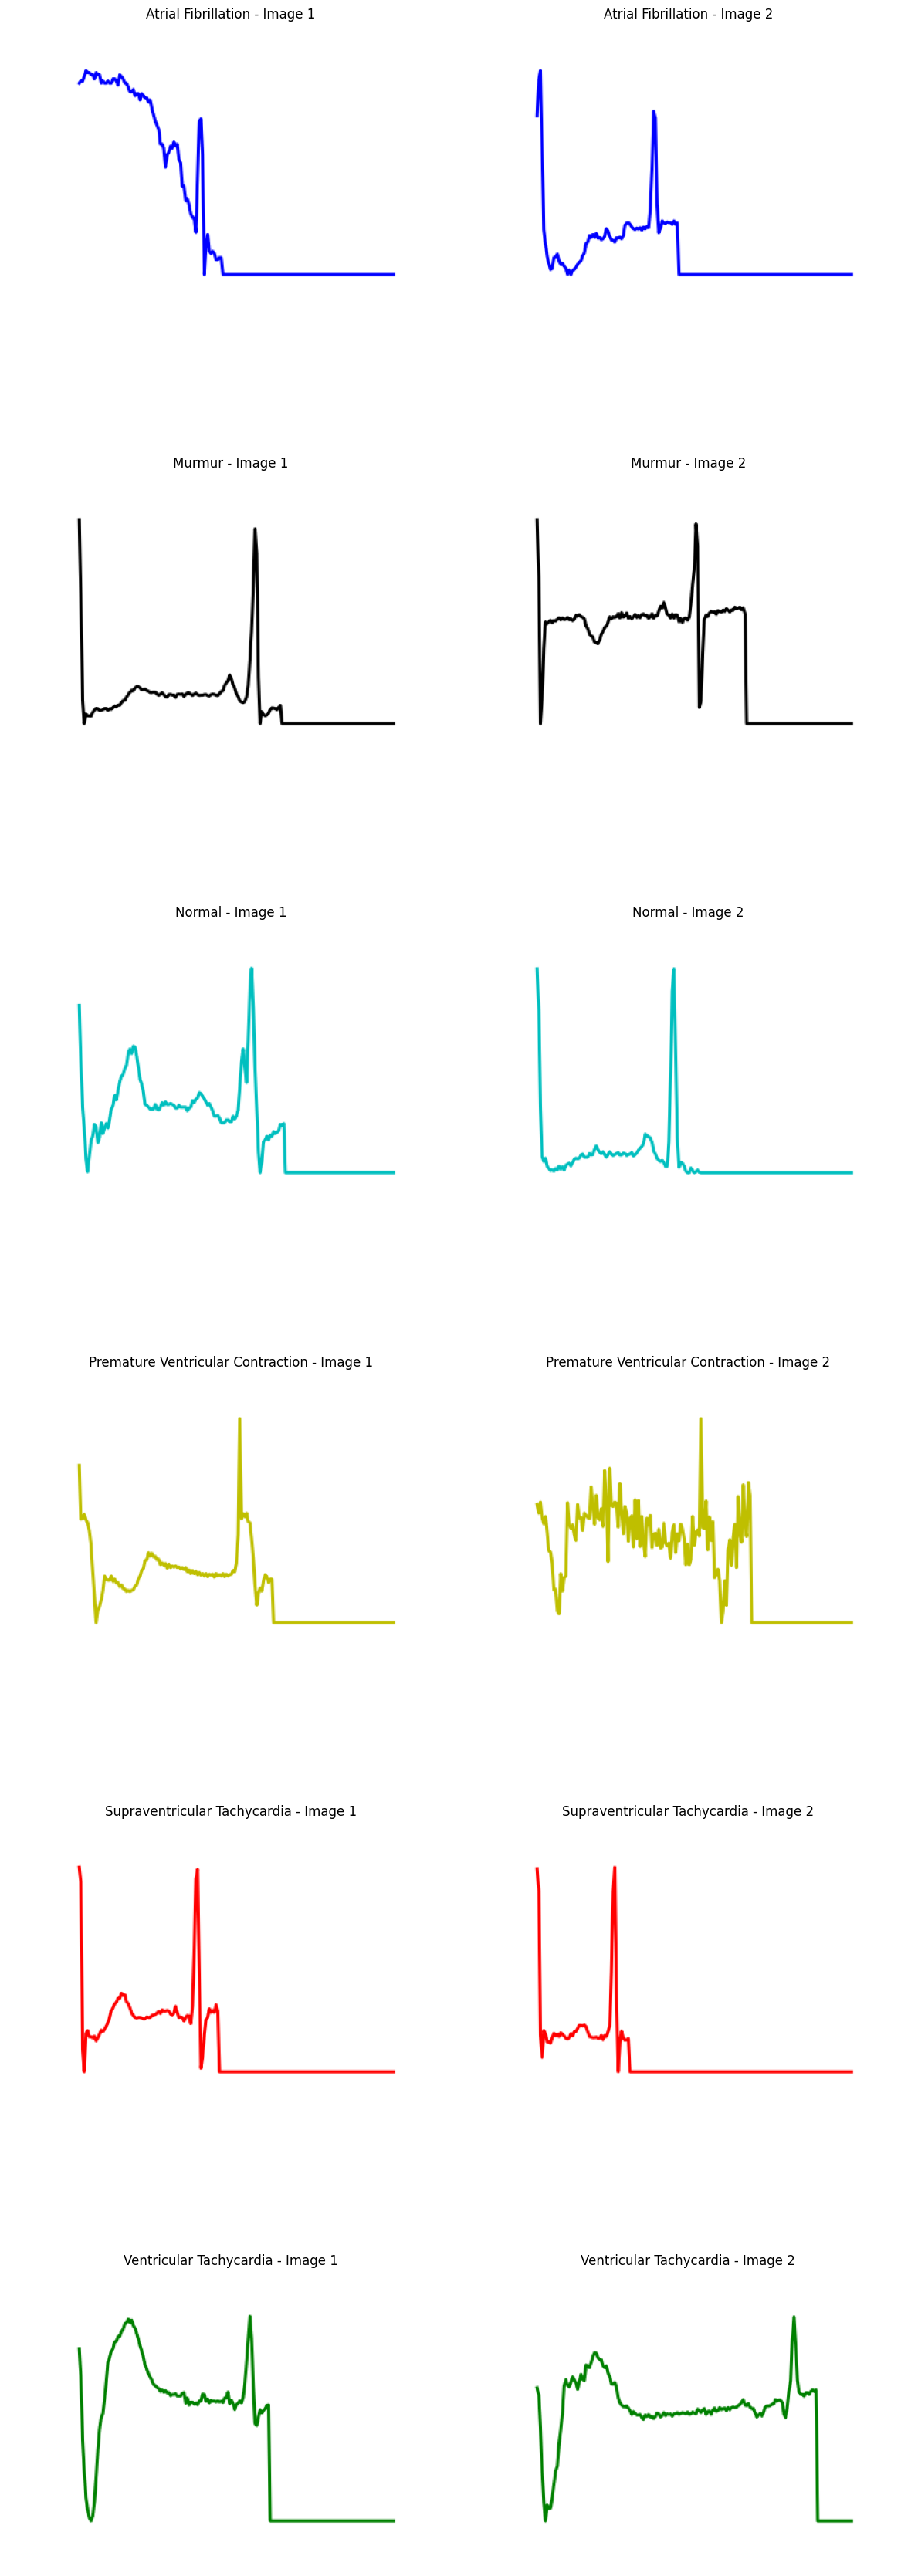

In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to the train directory
train_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/train'

# Class labels corresponding to folder names
labels_dict = {
    'F': 'Atrial Fibrillation',
    'M': 'Murmur',
    'N': 'Normal',
    'Q': 'Premature Ventricular Contraction',
    'S': 'Supraventricular Tachycardia',
    'V': 'Ventricular Tachycardia'
}

# Function to load images for each class
def load_images_for_class(class_name, num_images=2):
    class_folder = os.path.join(train_dir, class_name)
    images = []
    for filename in os.listdir(class_folder)[:num_images]:
        image_path = os.path.join(class_folder, filename)
        images.append(image_path)
    return images

# Calculate the number of rows based on the number of classes
num_classes = len(labels_dict)
num_images_per_class = 2  # Number of images per class
rows = num_classes  # Each class will take one row with two images

# Set up the plot size dynamically based on the number of rows and images per row
fig, axes = plt.subplots(rows, num_images_per_class, figsize=(12, rows*6))
axes = axes.ravel()  # Flatten the axes to make it easier to index

# Loop through each class and display two images side by side
for idx, (class_key, class_label) in enumerate(labels_dict.items()):
    images = load_images_for_class(class_key, num_images=num_images_per_class)
    
    for i, image_path in enumerate(images):
        img = mpimg.imread(image_path)
        ax = axes[idx * num_images_per_class + i]  # Select the correct subplot
        ax.imshow(img)
        ax.set_title(f"{class_label} - Image {i+1}")
        ax.axis('off')  # Hide axis

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


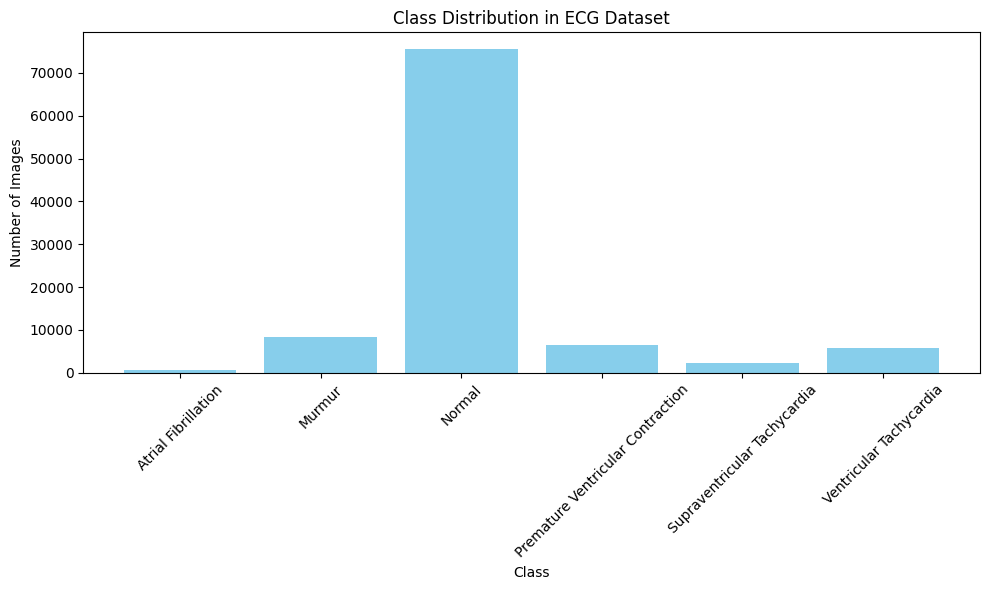

In [4]:
# Path to the train directory
train_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/train'

# Class labels corresponding to folder names
labels_dict = {
    'F': 'Atrial Fibrillation',
    'M': 'Murmur',
    'N': 'Normal',
    'Q': 'Premature Ventricular Contraction',
    'S': 'Supraventricular Tachycardia',
    'V': 'Ventricular Tachycardia'
}

# Function to count images for each class
def count_images_for_classes(directory):
    class_counts = {label: 0 for label in labels_dict.values()}
    for folder in os.listdir(directory):
        if folder in labels_dict:
            class_label = labels_dict[folder]
            class_folder = os.path.join(directory, folder)
            num_images = len(os.listdir(class_folder))
            class_counts[class_label] += num_images
    return class_counts

# Get the class distribution
class_distribution = count_images_for_classes(train_dir)

# Create a DataFrame for visualization
df_class_distribution = pd.DataFrame(list(class_distribution.items()), columns=['Class', 'Count'])

# Plot the class distribution
plt.figure(figsize=(10, 6))
plt.bar(df_class_distribution['Class'], df_class_distribution['Count'], color='skyblue')
plt.title('Class Distribution in ECG Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [5]:
df['label'].value_counts()

label
Normal                               94635
Murmur                               10506
Premature Ventricular Contraction     8039
Ventricular Tachycardia               7236
Supraventricular Tachycardia          2779
Atrial Fibrillation                    803
Name: count, dtype: int64

In [6]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get unique classes and counts
classes = np.unique(df['label'])
class_counts = df['label'].value_counts()

# Compute class weights (inverse frequency)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=df['label']
)

# Create a dict mapping label name to weight
class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:")
for label, weight in class_weight_dict.items():
    print(f"{label}: {weight:.2f}")

Class weights:
Atrial Fibrillation: 25.74
Murmur: 1.97
Normal: 0.22
Premature Ventricular Contraction: 2.57
Supraventricular Tachycardia: 7.44
Ventricular Tachycardia: 2.86


2026-01-05 07:15:58.319325: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767597358.507074      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767597358.567399      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767597359.009514      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767597359.009555      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767597359.009557      24 computation_placer.cc:177] computation placer alr

Class weights:
Atrial Fibrillation: 25.74
Murmur: 1.97
Normal: 0.22
Premature Ventricular Contraction: 2.57
Supraventricular Tachycardia: 7.44
Ventricular Tachycardia: 2.86
Found 99199 images belonging to 6 classes.
Found 24799 images belonging to 6 classes.


I0000 00:00:1767597457.172390      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


...

3100/3100 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.9734 - loss: 0.0932
Epoch 1: val_accuracy improved from -inf to 0.96661, saving model to best_mobilenet_model.h5


3100/3100 ━━━━━━━━━━━━━━━━━━━━ 1079s 344ms/step - accuracy: 0.9734 - loss: 0.0932 - val_accuracy: 0.9666 - val_loss: 0.0896
Epoch 2/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.9952 - loss: 0.0144
Epoch 2: val_accuracy improved from 0.96661 to 0.99016, saving model to best_mobilenet_model.h5


3100/3100 ━━━━━━━━━━━━━━━━━━━━ 860s 277ms/step - accuracy: 0.9952 - loss: 0.0144 - val_accuracy: 0.9902 - val_loss: 0.0289
Epoch 3/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.9960 - loss: 0.0114
Epoch 3: val_accuracy improved from 0.99016 to 0.99605, saving model to best_mobilenet_model.h5


3100/3100 ━━━━━━━━━━━━━━━━━━━━ 846s 273ms/step - accuracy: 0.9960 - loss: 0.0114 - val_accuracy: 0.9960 - val_loss: 0.0126
Epoch 4/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.9964 - loss: 0.0110
Epoch 4: val_accuracy improved from 0.99605 to 0.99718, saving model to best_mobilenet_model.h5


3100/3100 ━━━━━━━━━━━━━━━━━━━━ 876s 283ms/step - accuracy: 0.9964 - loss: 0.0110 - val_accuracy: 0.9972 - val_loss: 0.0079
Epoch 5/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.9969 - loss: 0.0097
Epoch 5: val_accuracy did not improve from 0.99718
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 827s 267ms/step - accuracy: 0.9969 - loss: 0.0097 - val_accuracy: 0.9721 - val_loss: 0.0859
Epoch 6/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.9974 - loss: 0.0077
Epoch 6: val_accuracy did not improve from 0.99718
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 832s 268ms/step - accuracy: 0.9974 - loss: 0.0077 - val_accuracy: 0.9909 - val_loss: 0.0259
Epoch 7/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.9975 - loss: 0.0079
Epoch 7: val_accuracy did not improve from 0.99718
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 869s 280ms/step - accuracy: 0.9975 - loss: 0.0079 - val_accuracy: 0.9905 - val_loss: 0.0276
Epoch 8/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.9975 - loss: 0.

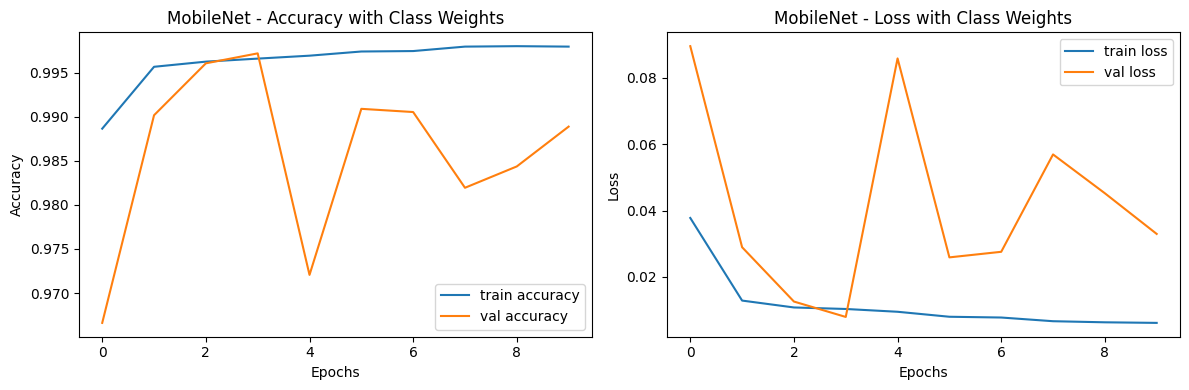

775/775 ━━━━━━━━━━━━━━━━━━━━ 77s 93ms/step - accuracy: 0.9975 - loss: 0.0072
Test Accuracy of Best Model: 0.9971773028373718
Test Loss of Best Model: 0.007927806116640568
775/775 ━━━━━━━━━━━━━━━━━━━━ 78s 95ms/step


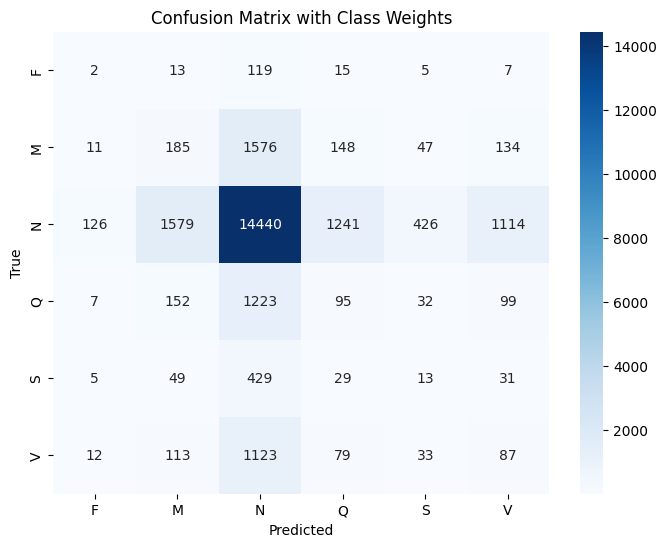

Classification Report with Class Weights:
              precision    recall  f1-score   support

           F       0.01      0.01      0.01       161
           M       0.09      0.09      0.09      2101
           N       0.76      0.76      0.76     18926
           Q       0.06      0.06      0.06      1608
           S       0.02      0.02      0.02       556
           V       0.06      0.06      0.06      1447

    accuracy                           0.60     24799
   macro avg       0.17      0.17      0.17     24799
weighted avg       0.60      0.60      0.60     24799



In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Assuming `df` is your DataFrame with the 'label' column
# If you haven't done that yet, here is how to get the class weights:

# Get unique classes and counts
classes = np.unique(df['label'])
class_counts = df['label'].value_counts()

# Compute class weights (inverse frequency)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=df['label']
)

# Create a dict mapping label name to weight
class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:")
for label, weight in class_weight_dict.items():
    print(f"{label}: {weight:.2f}")


# Paths to your dataset
train_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/train'
test_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/test'

# Image size for resizing (MobileNet, CNN, etc.)
IMG_SIZE = (160, 160)

# Data Preprocessing and Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical'
)

# Define MobileNet Model
def create_mobilenet_model():
    base_model = MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')
    base_model.trainable = False  # Freeze base model layers

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(6, activation='softmax')  # 6 classes
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create Model
model = create_mobilenet_model()

# Define ModelCheckpoint callback to save the best model
checkpoint = ModelCheckpoint(
    'best_mobilenet_model.h5',  # File to save the best model
    monitor='val_accuracy',  # Monitor validation accuracy
    mode='max',  # Save the model when val_accuracy improves
    save_best_only=True,  # Save only the best model
    verbose=1
)

# Train the model with class weights and ModelCheckpoint
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    class_weight=class_weight_dict,  # Add class weights here
    callbacks=[checkpoint]  # Use the ModelCheckpoint callback
)

# Save the final model after training
model.save('mobilenet_ecg_model_final.h5')

# Plot Accuracy and Loss Curves
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('MobileNet - Accuracy with Class Weights')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('MobileNet - Loss with Class Weights')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate the best model (which was saved by ModelCheckpoint)
best_model = models.load_model('best_mobilenet_model.h5')
test_loss, test_acc = best_model.evaluate(test_generator)
print(f"Test Accuracy of Best Model: {test_acc}")
print(f"Test Loss of Best Model: {test_loss}")

# Predictions on Test Data using the best model
y_pred = best_model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix with Class Weights')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report
report = classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys())
print(f"Classification Report with Class Weights:")
print(report)


In [8]:
# import os
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report, confusion_matrix
# import seaborn as sns
# import tensorflow as tf
# from tensorflow.keras import layers, models
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.applications import MobileNetV2

# # Paths to your dataset
# train_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/train'
# test_dir = '/kaggle/input/ecg-image-data/ECG_Image_data/test'

# # Class labels corresponding to folder names
# labels_dict = {
#     'F': 'Atrial Fibrillation',
#     'M': 'Murmur',
#     'N': 'Normal',
#     'Q': 'Premature Ventricular Contraction',
#     'S': 'Supraventricular Tachycardia',
#     'V': 'Ventricular Tachycardia'
# }

# # Image size for resizing (MobileNet, CNN, etc.)
# IMG_SIZE = (160, 160)

# # Data Preprocessing and Augmentation
# train_datagen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=40,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     shear_range=0.2,
#     zoom_range=0.2,
#     horizontal_flip=True,
#     fill_mode='nearest'
# )

# test_datagen = ImageDataGenerator(rescale=1./255)

# train_generator = train_datagen.flow_from_directory(
#     train_dir,
#     target_size=IMG_SIZE,
#     batch_size=32,
#     class_mode='categorical'
# )

# test_generator = test_datagen.flow_from_directory(
#     test_dir,
#     target_size=IMG_SIZE,
#     batch_size=32,
#     class_mode='categorical'
# )

# # Split data into training and validation sets
# X_train, X_val, y_train, y_val = train_test_split(
#     np.array([train_generator.filepaths]),
#     np.array([train_generator.classes]),
#     test_size=0.2, random_state=42
# )

# # Define CNN Model
# def create_cnn_model():
#     model = models.Sequential([
#         layers.Conv2D(32, (3, 3), activation='relu', input_shape=(160, 160, 3)),
#         layers.MaxPooling2D((2, 2)),
#         layers.Conv2D(64, (3, 3), activation='relu'),
#         layers.MaxPooling2D((2, 2)),
#         layers.Conv2D(128, (3, 3), activation='relu'),
#         layers.MaxPooling2D((2, 2)),
#         layers.Flatten(),
#         layers.Dense(128, activation='relu'),
#         layers.Dense(6, activation='softmax')  # 6 classes
#     ])
#     model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
#     return model

# # Define CNN 2D Model
# def create_cnn2d_model():
#     model = models.Sequential([
#         layers.Conv2D(64, (3, 3), activation='relu', input_shape=(160, 160, 3)),
#         layers.MaxPooling2D((2, 2)),
#         layers.Conv2D(128, (3, 3), activation='relu'),
#         layers.MaxPooling2D((2, 2)),
#         layers.Conv2D(256, (3, 3), activation='relu'),
#         layers.MaxPooling2D((2, 2)),
#         layers.Flatten(),
#         layers.Dense(256, activation='relu'),
#         layers.Dense(6, activation='softmax')  # 6 classes
#     ])
#     model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
#     return model

# # Define MobileNet Model
# def create_mobilenet_model():
#     base_model = MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')
#     base_model.trainable = False  # Freeze base model layers

#     model = models.Sequential([
#         base_model,
#         layers.GlobalAveragePooling2D(),
#         layers.Dense(128, activation='relu'),
#         layers.Dense(6, activation='softmax')  # 6 classes
#     ])
#     model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
#     return model

# # Choose model type (CNN, CNN2D, or MobileNet)
# model_type = 'MobileNet'  # Change this to 'CNN' or 'CNN2D' to use those models

# if model_type == 'CNN':
#     model = create_cnn_model()
# elif model_type == 'CNN2D':
#     model = create_cnn2d_model()
# else:
#     model = create_mobilenet_model()

# # Train the model
# history = model.fit(
#     train_generator,
#     epochs=10,
#     validation_data=test_generator
# )

# # Save the model
# model.save(f'{model_type}_ecg_model.h5')

# # Plot Accuracy and Loss Curves
# plt.figure(figsize=(12, 4))

# # Accuracy Plot
# plt.subplot(1, 2, 1)
# plt.plot(history.history['accuracy'], label='train accuracy')
# plt.plot(history.history['val_accuracy'], label='val accuracy')
# plt.title(f'{model_type} - Accuracy')
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.legend()

# # Loss Plot
# plt.subplot(1, 2, 2)
# plt.plot(history.history['loss'], label='train loss')
# plt.plot(history.history['val_loss'], label='val loss')
# plt.title(f'{model_type} - Loss')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.legend()

# plt.tight_layout()
# plt.show()

# # Evaluate the model on test data
# test_loss, test_acc = model.evaluate(test_generator)
# print(f"Test Accuracy: {test_acc}")
# print(f"Test Loss: {test_loss}")

# # Predictions on Test Data
# y_pred = model.predict(test_generator, verbose=1)
# y_pred_classes = np.argmax(y_pred, axis=1)
# y_true = test_generator.classes

# # Confusion Matrix
# cm = confusion_matrix(y_true, y_pred_classes)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
# plt.title(f'{model_type} - Confusion Matrix')
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.show()

# # Classification Report
# report = classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys())
# print(f"{model_type} - Classification Report:")
# print(report)
